In [ ]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# 회귀모형

In [ ]:
# Load Example Data
tips = sns.load_dataset("tips")
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


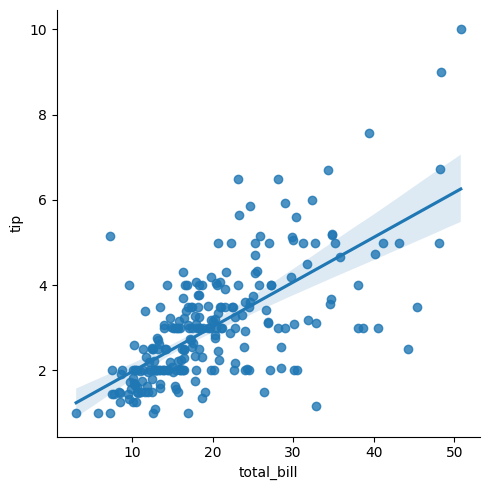

In [ ]:
sns.lmplot(data = tips, x = "total_bill", y = "tip")

## `statsmodels.api` 의 `OLS` 함수로 회귀식 적합

In [ ]:
import statsmodels.api as sm

x = tips.total_bill.values.reshape(-1,1)
y = tips.tip.values.reshape(-1,1)
X = sm.add_constant(x)

In [ ]:
ols = sm.OLS(y, X)
results = ols.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.457
Model:                            OLS   Adj. R-squared:                  0.454
Method:                 Least Squares   F-statistic:                     203.4
Date:                Wed, 26 Feb 2025   Prob (F-statistic):           6.69e-34
Time:                        05:16:43   Log-Likelihood:                -350.54
No. Observations:                 244   AIC:                             705.1
Df Residuals:                     242   BIC:                             712.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9203      0.160      5.761      0.0

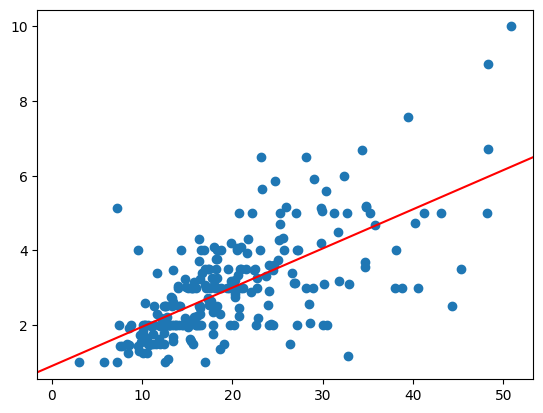

In [ ]:
beta0, beta1 = results.params

fig, ax = plt.subplots()
ax.scatter(x, y)
ax.axline((beta0, 1), slope = beta1, color='red')
plt.show()

## 회귀식의 $\beta$ 값 직접 계산

In [ ]:
df = tips.iloc[:,0:2]
mx, my = df.mean()
sx, sy = df.std()
sxy = df.cov().values[0,1]
beta1 = sxy/sx**2

In [ ]:
beta1 = sxy/sx**2
beta0 = my - beta1 * mx
print(f"beta0, beta1 : {round(beta0,4)}, {round(beta1,4)}")

beta0, beta1 : 0.9203, 0.105


# 비선형 회귀모형

In [ ]:
import random
import statsmodels.api as sm

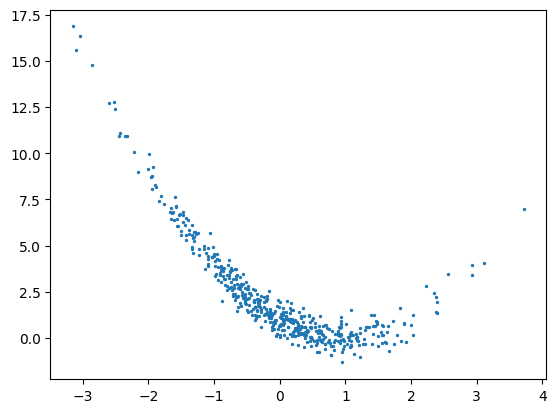

In [ ]:
random.seed(1)
n = 500
x = np.random.normal(0, 1, n)
#X = sm.add_constant(x)
X = np.concatenate((np.ones(n), x)).reshape(2, n).T
y = (x-1)**2 + np.random.normal(0, 0.5, n)

plt.scatter(x, y, s = 2)
plt.show()

In [ ]:
ols = sm.OLS(y, X)
results = ols.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.595
Model:                            OLS   Adj. R-squared:                  0.594
Method:                 Least Squares   F-statistic:                     732.5
Date:                Wed, 26 Feb 2025   Prob (F-statistic):          7.00e-100
Time:                        05:16:43   Log-Likelihood:                -983.65
No. Observations:                 500   AIC:                             1971.
Df Residuals:                     498   BIC:                             1980.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.0890      0.078     26.929      0.0

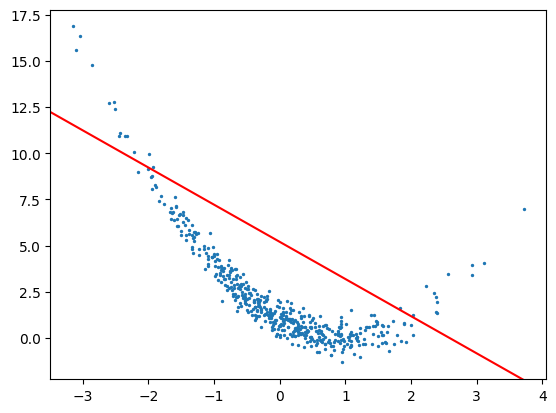

In [ ]:
y_hat = results.fittedvalues
beta0, beta1 = results.params

fig, ax = plt.subplots()
ax.scatter(x, y, s = 2)
ax.axline((beta0, 1), slope = beta1, color='red')
plt.show()

## 다항회귀 (Polynomial Regression)

$$y_i = \beta_0 + \beta_1 x_i + \beta_2 x_i^2 + \epsilon_i$$

In [ ]:
x2 = x**2
X2 = np.concatenate((np.ones(n), x, x2)).reshape(3,n).T

ols2 = sm.OLS(y, X2)
results2 = ols2.fit()
print(results2.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.965
Model:                            OLS   Adj. R-squared:                  0.964
Method:                 Least Squares   F-statistic:                     6776.
Date:                Wed, 26 Feb 2025   Prob (F-statistic):               0.00
Time:                        05:17:28   Log-Likelihood:                -374.35
No. Observations:                 500   AIC:                             754.7
Df Residuals:                     497   BIC:                             767.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.0274      0.027     37.658      0.0

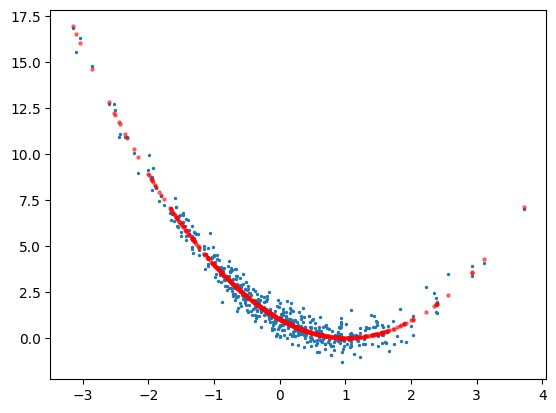

In [ ]:
y_hat2 = results2.fittedvalues

fig, ax = plt.subplots()
ax.scatter(x, y, s = 2)
ax.scatter(x, y_hat2, color = "red", s = 5, alpha = 0.5)
plt.show()

In [ ]:
# for higher order
x3 = x**3
X3 = np.concatenate((np.ones(n), x, x2, x3)).reshape(4,n).T
ols3 = sm.OLS(y, X3)
results3 = ols3.fit()
print(results3.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.965
Model:                            OLS   Adj. R-squared:                  0.964
Method:                 Least Squares   F-statistic:                     4516.
Date:                Wed, 26 Feb 2025   Prob (F-statistic):               0.00
Time:                        05:17:56   Log-Likelihood:                -373.93
No. Observations:                 500   AIC:                             755.9
Df Residuals:                     496   BIC:                             772.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.0282      0.027     37.663      0.0

In [ ]:
# numpy array 인 x, y 를 sns.regplot 에 들어갈수 있는 형태인 pandas 데이터프레임 형태로 만들어줌.
df = pd.DataFrame(np.concatenate((x, y)).reshape(2,n).T,
                  columns = ["x", "y"])
df

,x,y
0,0.465939,-0.135839
1,-0.479070,1.404809
2,-1.549082,6.060281
3,2.219841,2.802592
4,1.083915,1.506934
...,...,...
495,-1.604336,6.365590
496,-1.333175,6.086889
497,1.555379,-0.251715
498,2.386557,1.420168


<Axes: xlabel='x', ylabel='y'>

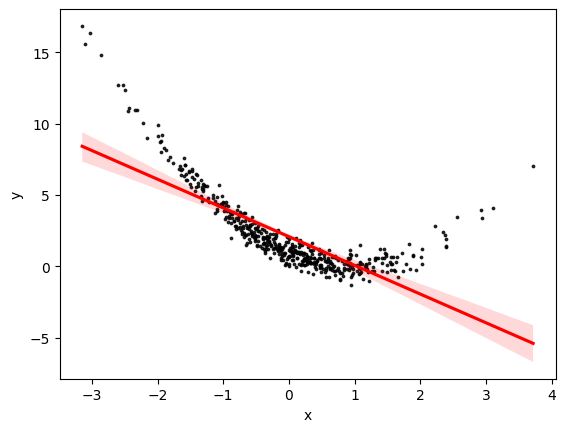

In [ ]:
# plot : order 1
sns.regplot(data = df, x = "x", y = "y",
            scatter_kws = {"color": "black", "s": 3},
            line_kws = {"color": "red"})

<Axes: xlabel='x', ylabel='y'>

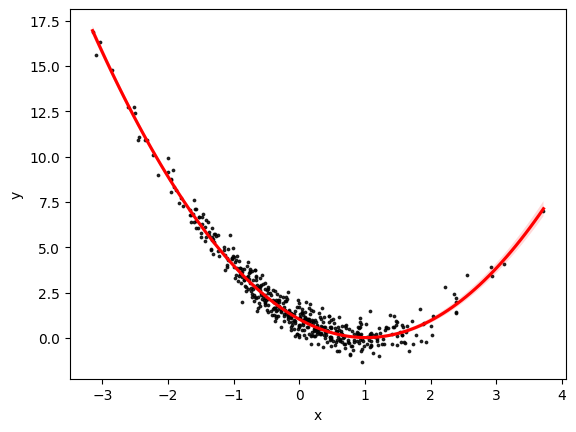

In [ ]:
# plot : order 2
sns.regplot(data = df, x = "x", y = "y", order = 2,
            scatter_kws = {"color": "black", "s": 3},
            line_kws = {"color": "red"})

# 범주형 vs. 연속형 변수의 관계

## 종속변수가 연속형인 경우

<Axes: xlabel='day', ylabel='total_bill'>

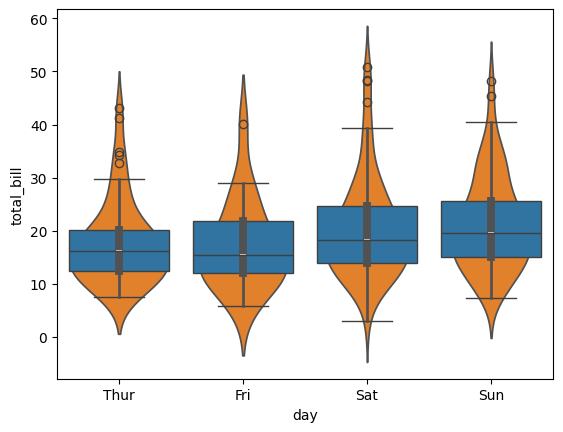

In [ ]:
# boxplot, violin plot
# total_bill (연속형 변수) 가 y 일때
sns.boxplot(tips, x = "day", y = "total_bill")
sns.violinplot(tips, x = "day", y = "total_bill")

In [ ]:
# t-test, ANOVA (Analysis of Variance)
from statsmodels.formula.api import ols

model = ols('total_bill ~ day', tips).fit()
sm.stats.anova_lm(model)

,df,sum_sq,mean_sq,F,PR(>F)
day,3.0,643.941362,214.647121,2.767479,0.042454
Residual,240.0,18614.522721,77.560511,NaN,NaN


## 종속변수가 범주형인 경우

In [ ]:
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


<Axes: xlabel='total_bill', ylabel='sex'>

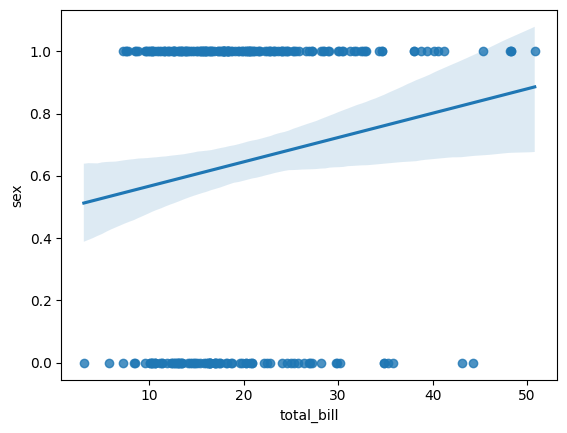

In [66]:
# sex (범주형 변수) 가 y 일때
# sns.regplot 에 범주형 변수를 넣으려면 숫자로 변화시켜줘야함. Male, Female 값을 1,0으로 변환

tips['m'] = tips['sex'].map({'Male': 1, 'Female': 0})
sns.regplot(data = tips, x = "total_bill", y = "sex")

<Axes: xlabel='total_bill', ylabel='sex'>

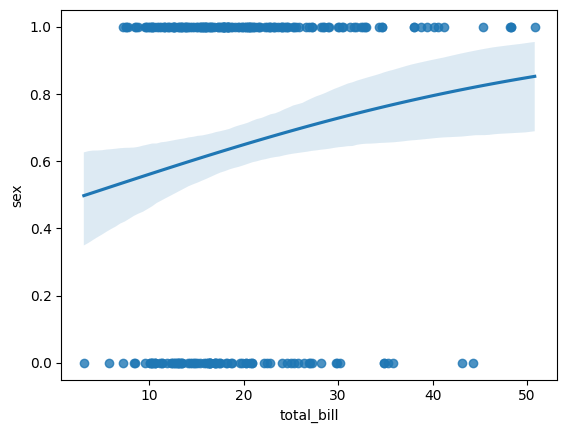

In [67]:
sns.regplot(data = tips, x = "total_bill", y = "sex", logistic = True)

## 범주형 변수의 관계

In [ ]:
# 분할표 (Cross Table, Contingency Table)
temp = tips.groupby(['sex', 'smoker', 'time']).count().iloc[:,0]
table = temp.unstack()
table

time        Lunch  Dinner
sex smoker               
1   Yes        13      47
    No         20      77
0   Yes        10      23
    No         25      29

In [ ]:
# Pearson chi-square test
from scipy.stats import chi2_contingency
chi2_contingency(table)

Chi2ContingencyResult(statistic=12.903788461177925, pvalue=0.004849356106612451, dof=3, expected_freq=array([[16.72131148, 43.27868852],
       [27.03278689, 69.96721311],
       [ 9.19672131, 23.80327869],
       [15.04918033, 38.95081967]]))

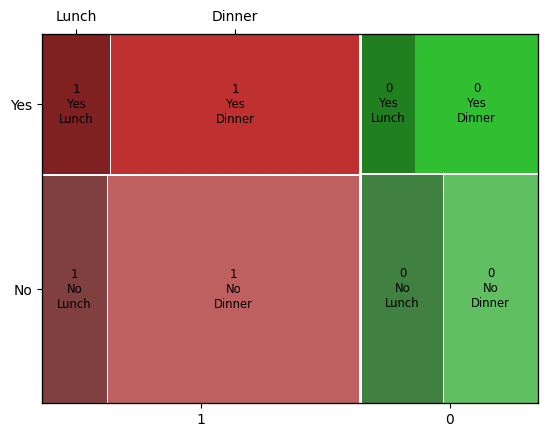

In [ ]:
# Mosaic Plot
from statsmodels.graphics.mosaicplot import mosaic

mosaic(tips.sort_values('sex'), ['sex', 'smoker', 'time'])
plt.show()